# 01. Favorita 판매 데이터 탐색

판매 규모와 시간 패턴, 프로모션 효과를 확인합니다. 모델링에 사용할 수 없는 미래 정보는 만들지 않습니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw"

In [2]:
def load_data(raw_path):
    train = pd.read_csv(
        raw_path / "train.csv",
        usecols=["date", "store_nbr", "family", "sales", "onpromotion"],
        parse_dates=["date"],
        dtype={"store_nbr": "int16", "family": "category", "sales": "float32", "onpromotion": "int16"},
    )
    stores = pd.read_csv(raw_path / "stores.csv")
    transactions = pd.read_csv(raw_path / "transactions.csv", parse_dates=["date"])
    return train, stores, transactions


def data_summary(frame):
    return pd.DataFrame({
        "value": [
            len(frame),
            frame["date"].min().date(),
            frame["date"].max().date(),
            frame["store_nbr"].nunique(),
            frame["family"].nunique(),
            frame["sales"].isna().sum(),
            frame["onpromotion"].isna().sum(),
        ]
    }, index=["rows", "start_date", "end_date", "stores", "families", "missing_sales", "missing_promotion"])


def daily_sales(frame):
    return frame.groupby("date", as_index=False, observed=True)["sales"].sum()


def promotion_summary(frame):
    return (
        frame.assign(promoted=frame["onpromotion"].gt(0))
        .groupby("promoted", observed=True)["sales"]
        .agg(rows="size", mean="mean", median="median")
    )

In [3]:
train, stores, transactions = load_data(RAW_PATH)
data_summary(train)

,value
rows,3000888
start_date,2013-01-01
end_date,2017-08-15
stores,54
families,33
missing_sales,0
missing_promotion,0


## 데이터 Column 정의

### 핵심 판매 데이터: `train.csv`

| Column | 의미 | 모델에서의 역할 | 시점·주의사항 |
|---|---|---|---|
| `date` | 판매 기준일 | 날짜 정렬 및 목표일 생성 | 무작위 분할 대신 시간순 분할에 사용 |
| `store_nbr` | 점포 식별자 | 범주형 변수·시계열 그룹 기준 | 숫자의 크기 자체에는 순서 의미가 없음 |
| `family` | 상품군 | 범주형 변수·시계열 그룹 기준 | 상품군별 판매 규모 차이를 반영 |
| `sales` | 일별 판매량 | 예측 라벨, lag, 이동평균 | 목표일 이후 값은 입력에 사용하지 않음 |
| `onpromotion` | 프로모션 상품 수 | 현재 및 목표일의 사전 계획 변수 | 목표일 값은 실제 업무에서 미리 확정된 경우에만 사용 가능 |

### 보조 데이터

| 파일.Column | 의미 | 모델에서의 역할 | 시점·주의사항 |
|---|---|---|---|
| `stores.store_nbr` | 점포 식별자 | 판매 데이터와 결합 | 결합 키 |
| `stores.city` | 점포 도시 | 범주형 변수·지역 공휴일 연결 | 도시명 자체에 순서 의미가 없음 |
| `stores.state` | 점포 주 | 범주형 변수·지역 공휴일 연결 | 지역별 차이를 반영 |
| `stores.type` | 점포 유형 | 범주형 변수 | 유형별 운영 특성의 대리변수 |
| `stores.cluster` | 유사 점포 군집 | 범주형 변수 | 연속적인 수치로 해석하지 않음 |
| `transactions.transactions` | 점포의 일별 거래 건수 | 기준일의 점포 수요 수준 | 목표일 거래량은 사전에 알 수 없어 사용하지 않음 |
| `oil.dcoilwtico` | 일별 유가 | 목표일 외부 환경 변수 | 시간 추세의 대리변수일 가능성을 별도 검증 |
| `holidays_events.type` | 공휴일·행사 유형 | 휴일·이벤트 파생변수 | `Work Day`는 일반 휴일과 구분 |
| `holidays_events.locale` | 적용 지역 수준 | 점포별 휴일 연결 | National·Regional·Local 구분 |
| `holidays_events.locale_name` | 적용 지역명 | 도시·주와 결합 | `city`, `state`와 일치시켜 사용 |
| `holidays_events.description` | 휴일·행사 설명 | 지진 등 특정 이벤트 파생 | 자유 텍스트를 모델에 직접 입력하지 않음 |
| `holidays_events.transferred` | 휴일 이관 여부 | 실제 휴일 여부 판단 | 이관된 원래 날짜를 휴일로 처리하지 않음 |

## 판매량 분포

판매량은 오른쪽 꼬리가 길기 때문에 원자료와 `log1p` 변환 결과를 함께 확인합니다.

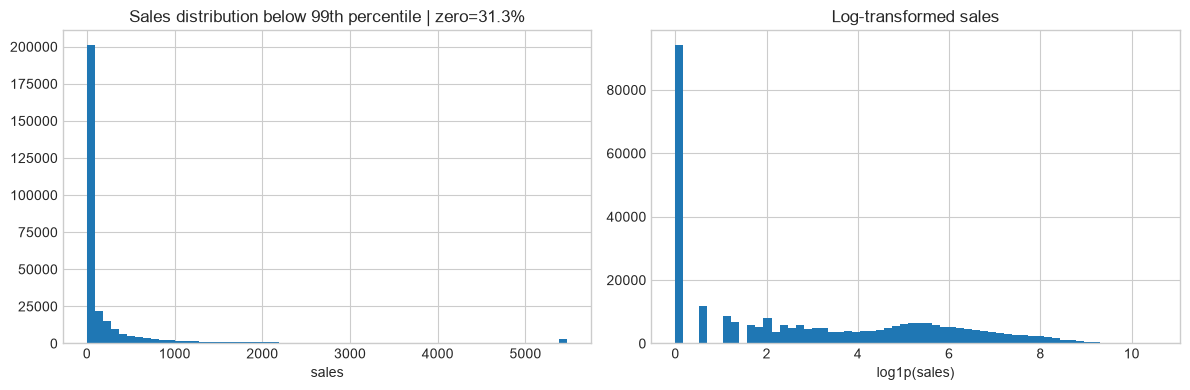

In [4]:
sample = train["sales"].sample(min(300_000, len(train)), random_state=42).clip(lower=0)
zero_rate = train["sales"].eq(0).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample.clip(upper=sample.quantile(0.99)), bins=60)
axes[1].hist(np.log1p(sample), bins=60)
axes[0].set(title=f"Sales distribution below 99th percentile | zero={zero_rate:.1%}", xlabel="sales")
axes[1].set(title="Log-transformed sales", xlabel="log1p(sales)")
plt.tight_layout()

## 전체 판매 추이와 요일 패턴

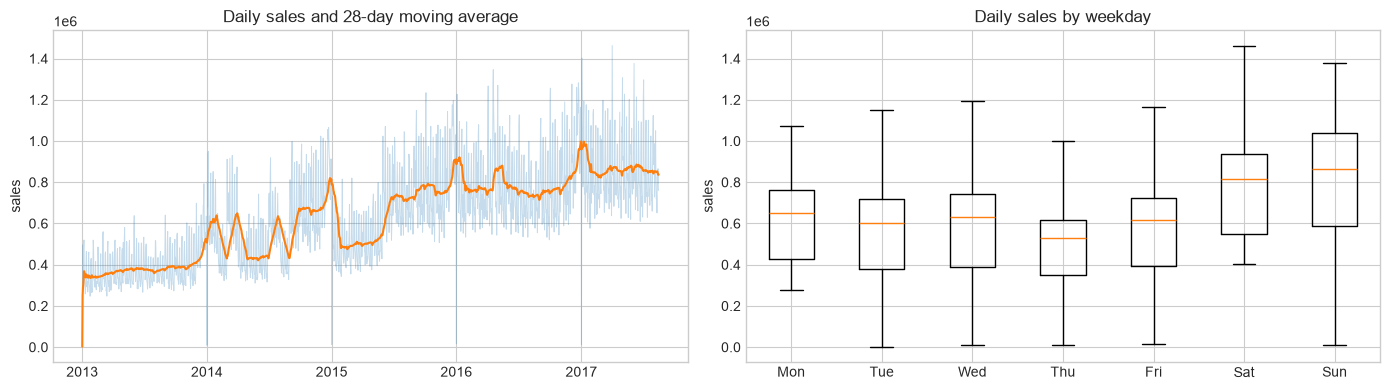

In [5]:
daily = daily_sales(train)
daily["rolling_28d"] = daily["sales"].rolling(28, min_periods=1).mean()
daily["dayofweek"] = daily["date"].dt.day_name().str[:3]
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(daily["date"], daily["sales"], alpha=0.25, linewidth=0.7)
axes[0].plot(daily["date"], daily["rolling_28d"], linewidth=1.5)
axes[0].set(title="Daily sales and 28-day moving average", xlabel="", ylabel="sales")
weekday_sales = [daily.loc[daily["dayofweek"].eq(day), "sales"] for day in weekday_order]
axes[1].boxplot(weekday_sales, tick_labels=weekday_order, showfliers=False)
axes[1].set(title="Daily sales by weekday", xlabel="", ylabel="sales")
plt.tight_layout()

## 상품군과 점포별 판매 규모

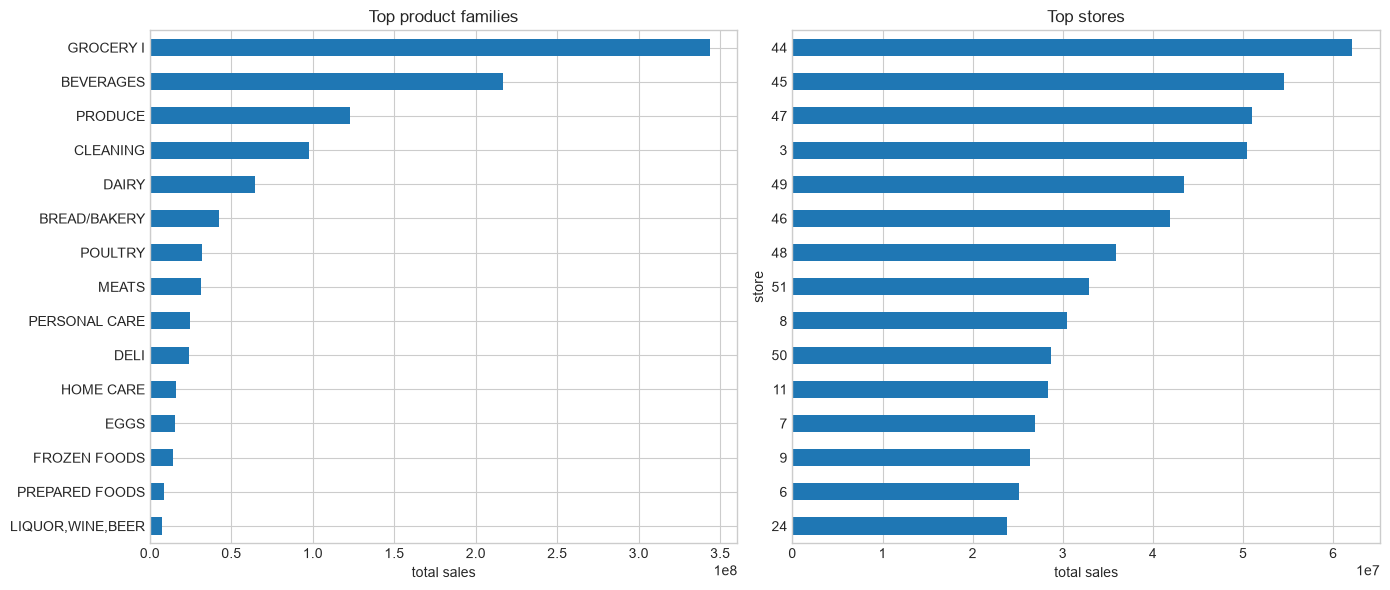

In [6]:
family_sales = (
    train.groupby("family", observed=True)["sales"].sum()
    .sort_values(ascending=False).head(15).sort_values()
)
store_sales = (
    train.groupby("store_nbr", observed=True)["sales"].sum()
    .sort_values(ascending=False).head(15).sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
family_sales.plot.barh(ax=axes[0], title="Top product families")
store_sales.plot.barh(ax=axes[1], title="Top stores")
axes[0].set(xlabel="total sales", ylabel="")
axes[1].set(xlabel="total sales", ylabel="store")
plt.tight_layout()

## 프로모션과 판매량

아래 차이는 인과효과가 아니라 단순 집단 비교입니다. 상품군과 시점이 다르므로 모델 변수의 필요성을 판단하는 탐색 결과로만 사용합니다.

In [7]:
promotion_summary(train)

,rows,mean,median
promoted,,,
False,2389559,158.246674,3.0
True,611329,1137.693726,373.0


In [8]:
promotion_by_family = (
    train.assign(promoted=train["onpromotion"].gt(0))
    .groupby(["family", "promoted"], observed=True)["sales"].mean()
    .unstack()
    .dropna()
)
promotion_by_family["mean_difference"] = promotion_by_family[True] - promotion_by_family[False]
promotion_by_family.sort_values("mean_difference", ascending=False).head(15)

promoted,False,True,mean_difference
family,,,
BEVERAGES,1292.272583,3215.498291,1923.225708
GROCERY I,2717.720703,4411.003418,1693.282715
PRODUCE,792.101929,2438.220215,1646.118286
DAIRY,479.811127,933.341736,453.530609
CLEANING,868.378296,1240.210693,371.832397
HOME CARE,101.956009,309.444855,207.488846
BREAD/BAKERY,379.513245,575.485291,195.972046
POULTRY,313.334503,485.006104,171.671600
MEATS,303.081085,467.301605,164.220520


## 상품군별 0 판매 비율

0 판매 비율이 높은 상품군은 절대오차보다 상대오차가 커질 수 있으므로 별도로 확인합니다.

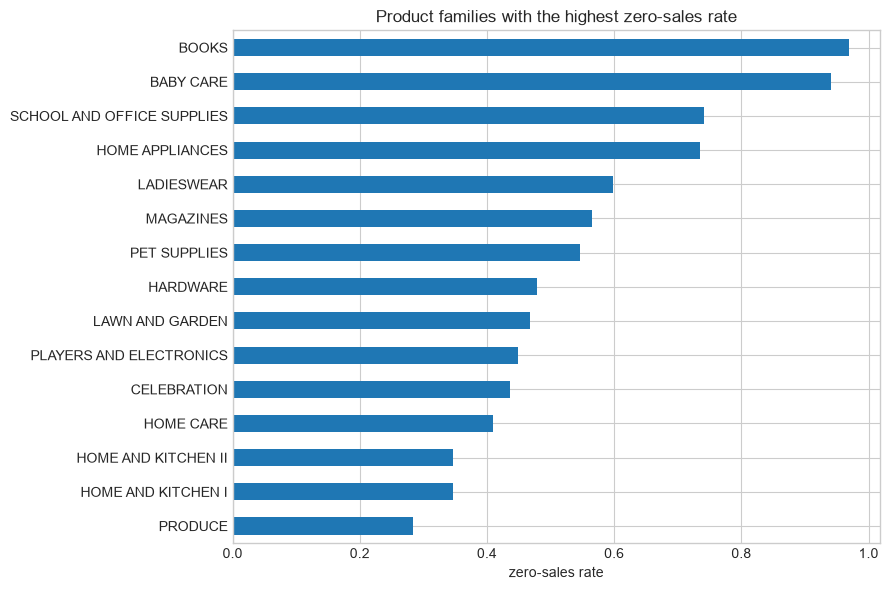

In [9]:
zero_rate_by_family = (
    train.assign(zero_sales=train["sales"].eq(0))
    .groupby("family", observed=True)["zero_sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
zero_rate_by_family.head(15).sort_values().plot.barh()
plt.title("Product families with the highest zero-sales rate")
plt.xlabel("zero-sales rate")
plt.ylabel("")
plt.tight_layout()

## 국가 공휴일과 전체 판매량

전국 단위 공휴일의 단순 비교이며 공휴일의 인과효과로 해석하지 않습니다.

In [10]:
holidays = pd.read_csv(RAW_PATH / "holidays_events.csv", parse_dates=["date"])
national_holiday_dates = holidays.loc[
    holidays["locale"].eq("National")
    & ~holidays["transferred"]
    & ~holidays["type"].eq("Work Day"),
    "date",
].unique()
holiday_sales = daily.assign(
    national_holiday=daily["date"].isin(national_holiday_dates)
).groupby("national_holiday")["sales"].agg(days="size", mean="mean", median="median")
holiday_sales

,days,mean,median
national_holiday,,,
False,1553,628031.6875,624711.3125
True,131,750471.6875,744956.9375


## 1차 확인 사항

- 판매량의 치우침과 0 판매 비율을 고려해 RMSLE를 주 지표로 사용합니다.
- 요일과 장기 추세가 보여 달력 변수와 과거 판매량 변수가 필요합니다.
- 프로모션 집단의 차이는 크지만 인과관계로 해석하지 않습니다.
- 상품군과 점포 간 판매 규모가 달라 범주형 변수를 유지합니다.
- 0 판매가 많은 상품군과 국가 공휴일은 오류 분석에서 별도 구간으로 확인합니다.